# Volume Reconstruction and Registration Exploration

This notebook explores the current pipeline in the project for:
- Loading and inspecting DICOM acquisitions
- Building 3D volumes directly from DICOM frame stacks
- Registering multiple reconstructed volumes
- Comparing alternative fusion strategies (mean, median, minimum, multiplication)

The flow mirrors `src/main.py` while replacing the AVI intermediate with direct DICOM-based reconstruction.

## 1) Environment and Imports

Napari is assumed to be installed and available in this environment.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pydicom
import SimpleITK as sitk
import matplotlib.pyplot as plt
import napari
from napari.utils import nbscreenshot

# Make project modules importable from this notebook location
PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / 'src'
UTILS_DIR = PROJECT_ROOT / 'utils'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
if str(UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(UTILS_DIR))

from volumeRegistrator import VolumeRegistrator

print(f'Project root: {PROJECT_ROOT}')
print(f'Source dir:   {SRC_DIR}')
print(f'Utils dir:    {UTILS_DIR}')

Project root: C:\Users\corba\Documents\eco-root
Source dir:   C:\Users\corba\Documents\eco-root\src
Utils dir:    C:\Users\corba\Documents\eco-root\utils


## 2) Configure Input/Output Paths

In [2]:
# Match the same acquisition used in src/main.py by default
dicom_input_dir = PROJECT_ROOT / 'data' / 'ultrasound' / 'raices reales' / '1'
mask_path = PROJECT_ROOT / 'data' / 'crop_masks' / 'mascara_no_borders_copy.png'
volumes_dir = PROJECT_ROOT / 'data' / 'volumes'
results_dir = PROJECT_ROOT / 'data' / 'results'

volumes_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

print('DICOM input:', dicom_input_dir)
print('Mask path:  ', mask_path)
print('Volumes dir:', volumes_dir)
print('Results dir:', results_dir)

DICOM input: C:\Users\corba\Documents\eco-root\data\ultrasound\raices reales\1
Mask path:   C:\Users\corba\Documents\eco-root\data\crop_masks\mascara_no_borders_copy.png
Volumes dir: C:\Users\corba\Documents\eco-root\data\volumes
Results dir: C:\Users\corba\Documents\eco-root\data\results


## 3) Load and Assess DICOM Images

Found 6 DICOM files in C:\Users\corba\Documents\eco-root\data\ultrasound\raices reales\1
Sample file: 001.dcm
Raw pixel array shape: (189, 768, 1024, 3)
Working stack shape: (189, 768, 1024)
Dtype: uint8
CineRate: 19
AcquisitionTime: 201406.235000


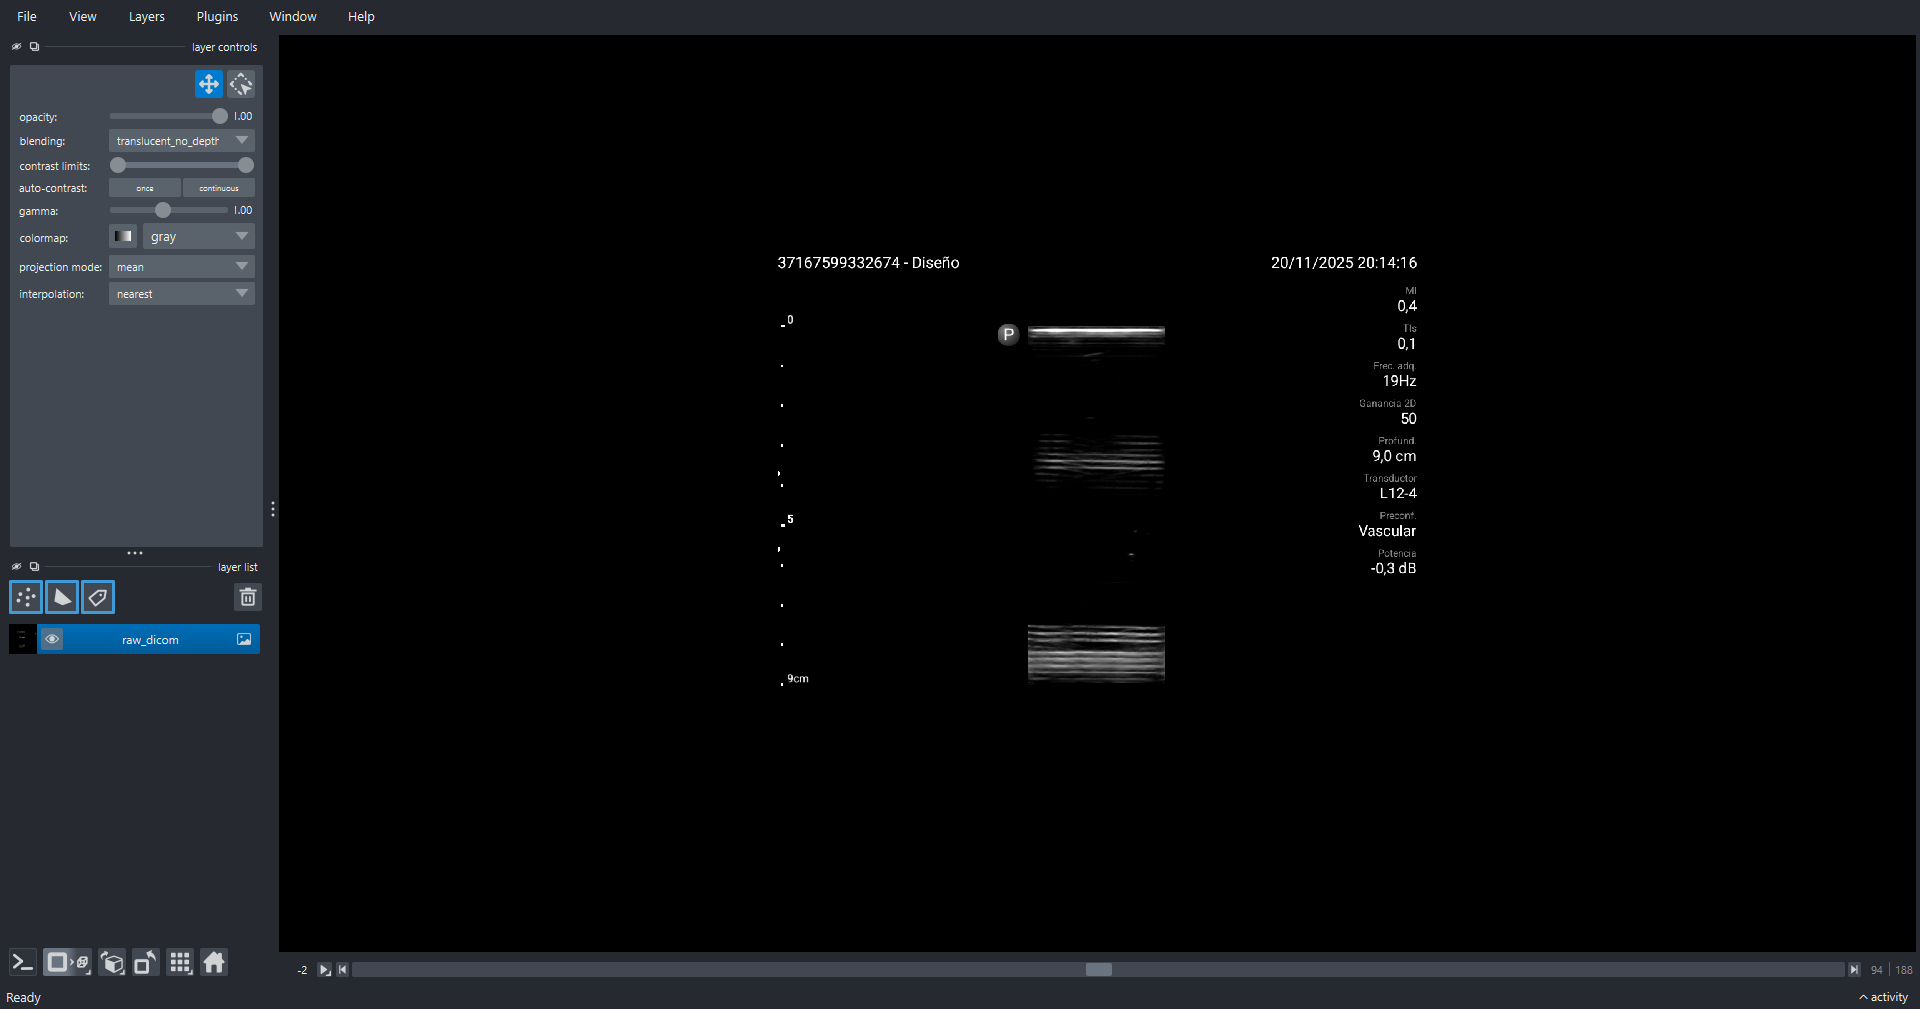

In [16]:
dicom_files = sorted(dicom_input_dir.glob('*.dcm'))
print(f'Found {len(dicom_files)} DICOM files in {dicom_input_dir}')
if len(dicom_files) == 0:
    raise FileNotFoundError(f'No DICOM files found in {dicom_input_dir}')

sample_dicom = dicom_files[0]
ds = pydicom.dcmread(sample_dicom)
raw = ds.pixel_array

# Assumption: DICOM data always has shape (z, y, x, channels).
# Channels are repeated because data is monochromatic, so keep one channel.
frames = raw[..., 0]

print('Sample file:', sample_dicom.name)
print('Raw pixel array shape:', raw.shape)
print('Working stack shape:', frames.shape)
print('Dtype:', frames.dtype)
print('CineRate:', ds.get('CineRate', 'N/A'))
print('AcquisitionTime:', ds.get('AcquisitionTime', 'N/A'))

# Open Napari with the raw loaded image stack.
viewer = napari.Viewer(title='Raw DICOM Assessment')
viewer.add_image(frames, name='raw_dicom', colormap='gray')
napari.run()

# Show screenshot as notebook output.
nbscreenshot(viewer)

## 4) Maximum Projections for Border Detection and Mask Design

This section computes a maximum intensity projection along z first, then builds x/y projection profiles and finds the largest contiguous non-zero region in each profile. For this acquisition, a manual mask override is also applied because the automatic bounds were not reliable enough.

Automatic largest contiguous bbox: y[98:578], x[401:619]
Using manual bbox override: y[116:689], x[401:619]


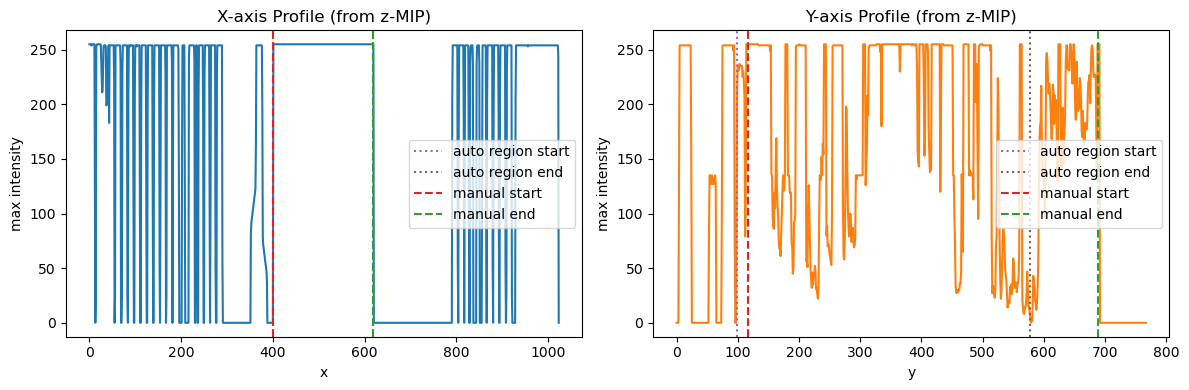

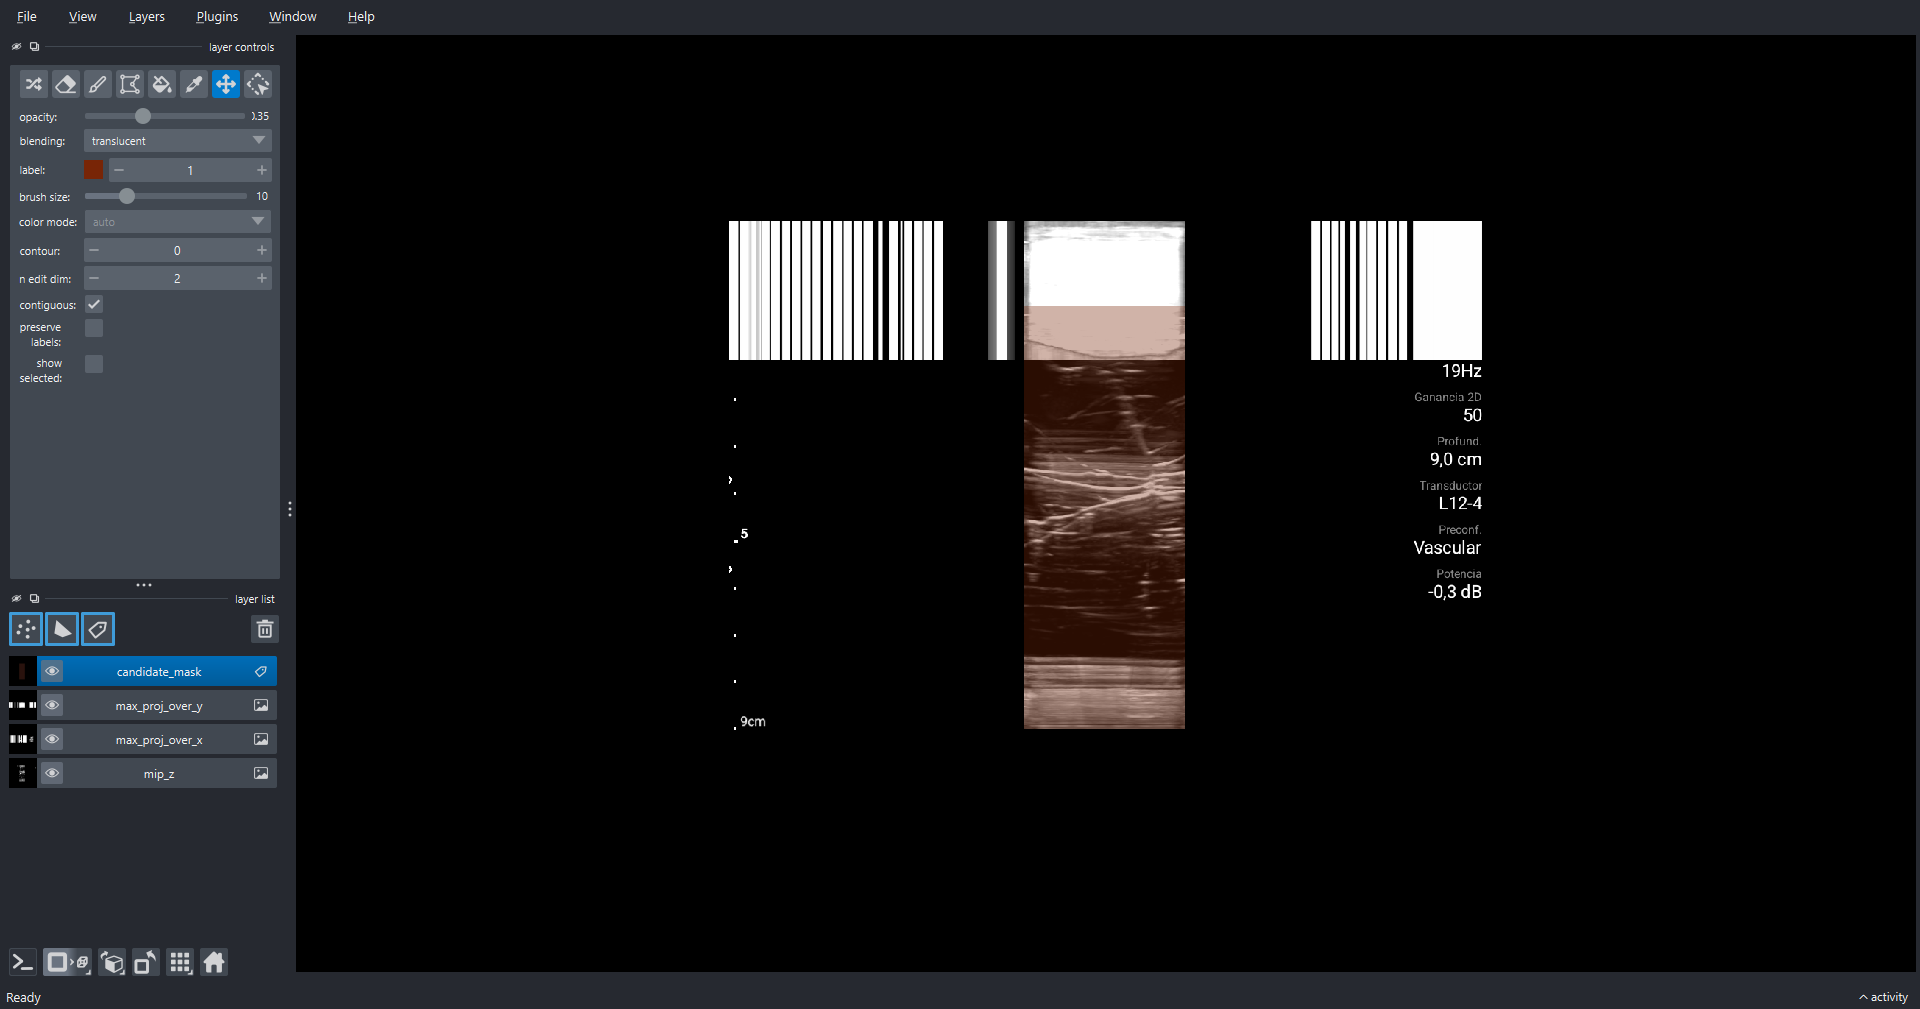

In [18]:
# Build max projections from the sample frame stack and derive a candidate mask.
# frames is expected to be (n_frames, height, width).
if frames.ndim == 2:
    frames_stack = frames[np.newaxis, ...]
else:
    frames_stack = frames

# 1) Maximum intensity projection across z (frame/depth).
mip_z = np.max(frames_stack, axis=0)  # -> (y, x)

# 2) Projection profiles across x and y axes from the z-MIP.
profile_x = np.max(mip_z, axis=0)  # intensity profile over x
profile_y = np.max(mip_z, axis=1)  # intensity profile over y

# Find largest contiguous non-zero region in x profile.
x_nonzero = np.where(profile_x > 0)[0]
if len(x_nonzero) == 0:
    raise ValueError('Could not detect non-zero x region from projection profile.')
x_breaks = np.where(np.diff(x_nonzero) > 1)[0] + 1
x_regions = np.split(x_nonzero, x_breaks)
x_largest = max(x_regions, key=len)
auto_min_x, auto_max_x = int(x_largest[0]), int(x_largest[-1])

# Find largest contiguous non-zero region in y profile.
y_nonzero = np.where(profile_y > 0)[0]
if len(y_nonzero) == 0:
    raise ValueError('Could not detect non-zero y region from projection profile.')
y_breaks = np.where(np.diff(y_nonzero) > 1)[0] + 1
y_regions = np.split(y_nonzero, y_breaks)
y_largest = max(y_regions, key=len)
auto_min_y, auto_max_y = int(y_largest[0]), int(y_largest[-1])

print(
    f'Automatic largest contiguous bbox: '
    f'y[{auto_min_y}:{auto_max_y}], x[{auto_min_x}:{auto_max_x}]'
 )

# Manual override for this acquisition because the automatic bounds were not reliable enough.
min_x, max_x = 401, 619
min_y, max_y = 116, 689
print(f'Using manual bbox override: y[{min_y}:{max_y}], x[{min_x}:{max_x}]')

# Plot projection profiles for quick visual validation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(profile_x, color='tab:blue', lw=1.5)
axes[0].axvline(auto_min_x, color='tab:purple', linestyle=':', label='auto region start')
axes[0].axvline(auto_max_x, color='tab:brown', linestyle=':', label='auto region end')
axes[0].axvline(min_x, color='tab:red', linestyle='--', label='manual start')
axes[0].axvline(max_x, color='tab:green', linestyle='--', label='manual end')
axes[0].set_title('X-axis Profile (from z-MIP)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('max intensity')
axes[0].legend()

axes[1].plot(profile_y, color='tab:orange', lw=1.5)
axes[1].axvline(auto_min_y, color='tab:purple', linestyle=':', label='auto region start')
axes[1].axvline(auto_max_y, color='tab:brown', linestyle=':', label='auto region end')
axes[1].axvline(min_y, color='tab:red', linestyle='--', label='manual start')
axes[1].axvline(max_y, color='tab:green', linestyle='--', label='manual end')
axes[1].set_title('Y-axis Profile (from z-MIP)')
axes[1].set_xlabel('y')
axes[1].set_ylabel('max intensity')
axes[1].legend()

plt.tight_layout()
plt.show()

# Candidate mask from the selected support.
candidate_mask = np.zeros_like(mip_z, dtype=bool)
candidate_mask[min_y:max_y + 1, min_x:max_x + 1] = True

# Keep additional projections for inspection.
max_proj_over_x = np.max(frames_stack, axis=2)  # -> (z, y)
max_proj_over_y = np.max(frames_stack, axis=1)  # -> (z, x)

viewer = napari.Viewer(title='Max Projection and Candidate Mask')
viewer.add_image(mip_z, name='mip_z', colormap='gray')
viewer.add_image(max_proj_over_x, name='max_proj_over_x', colormap='gray')
viewer.add_image(max_proj_over_y, name='max_proj_over_y', colormap='gray')
viewer.add_labels(candidate_mask.astype(np.uint8), name='candidate_mask', opacity=0.35)

nbscreenshot(viewer)

## 5) Reconstruct Volumes Directly from DICOM

In [19]:
# Build one 3D volume per DICOM file directly from its frame stack
voxel_spacing = (0.187, 0.188, 3.95)
sampling_rate = 3

# Prefer the bbox estimated from max projections (section 4).
if all(name in globals() for name in ['min_y', 'min_x', 'max_y', 'max_x']):
    min_y_i, min_x_i, max_y_i, max_x_i = int(min_y), int(min_x), int(max_y), int(max_x)
    print('Using bbox from max projection candidate mask.')
else:
    print('Falling back to mask file bbox from mask_path.')
    mask_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_path)))
    if mask_arr.ndim == 3:
        mask_arr = mask_arr[0]

    mask_bool = mask_arr > 0
    white_pixels = np.argwhere(mask_bool)
    if len(white_pixels) == 0:
        raise ValueError('Mask appears empty. Check mask_path.')

    min_coords = np.min(white_pixels, axis=0)
    max_coords = np.max(white_pixels, axis=0)
    min_y_i, min_x_i = min_coords.tolist()
    max_y_i, max_x_i = max_coords.tolist()

saved_volumes = []
for dcm_path in dicom_files:
    try:
        ds_i = pydicom.dcmread(dcm_path)
        raw_i = ds_i.pixel_array

        # Assumption: raw_i has shape (z, y, x, channels) and channels are repeated monochromatic data.
        frames_i = raw_i[..., 0]

        fps_i = float(ds_i.get('CineRate', 30))
        step_sampling = max(1, int(fps_i // sampling_rate))
        sampled = frames_i[::step_sampling]

        cropped = sampled[:, min_y_i:max_y_i, min_x_i:max_x_i].astype(np.float32)
        volume = sitk.GetImageFromArray(cropped)
        volume.SetSpacing(voxel_spacing)

        output_path = volumes_dir / f"volume_{dcm_path.stem}.nii.gz"
        sitk.WriteImage(volume, str(output_path))
        saved_volumes.append(output_path)
        print(f'Saved volume: {output_path.name} | shape={cropped.shape} | fps={fps_i}')
    except Exception as exc:
        print(f'Error processing {dcm_path.name}: {exc}')

print(f'Reconstructed {len(saved_volumes)} volumes from DICOM.')

Using bbox from max projection candidate mask.
Saved volume: volume_001.nii.gz | shape=(32, 573, 218) | fps=19.0
Saved volume: volume_002.nii.gz | shape=(32, 573, 218) | fps=19.0
Saved volume: volume_003.nii.gz | shape=(32, 573, 218) | fps=19.0
Saved volume: volume_004.nii.gz | shape=(32, 573, 218) | fps=19.0
Saved volume: volume_005.nii.gz | shape=(32, 573, 218) | fps=19.0
Saved volume: volume_006.nii.gz | shape=(32, 573, 218) | fps=19.0
Reconstructed 6 volumes from DICOM.


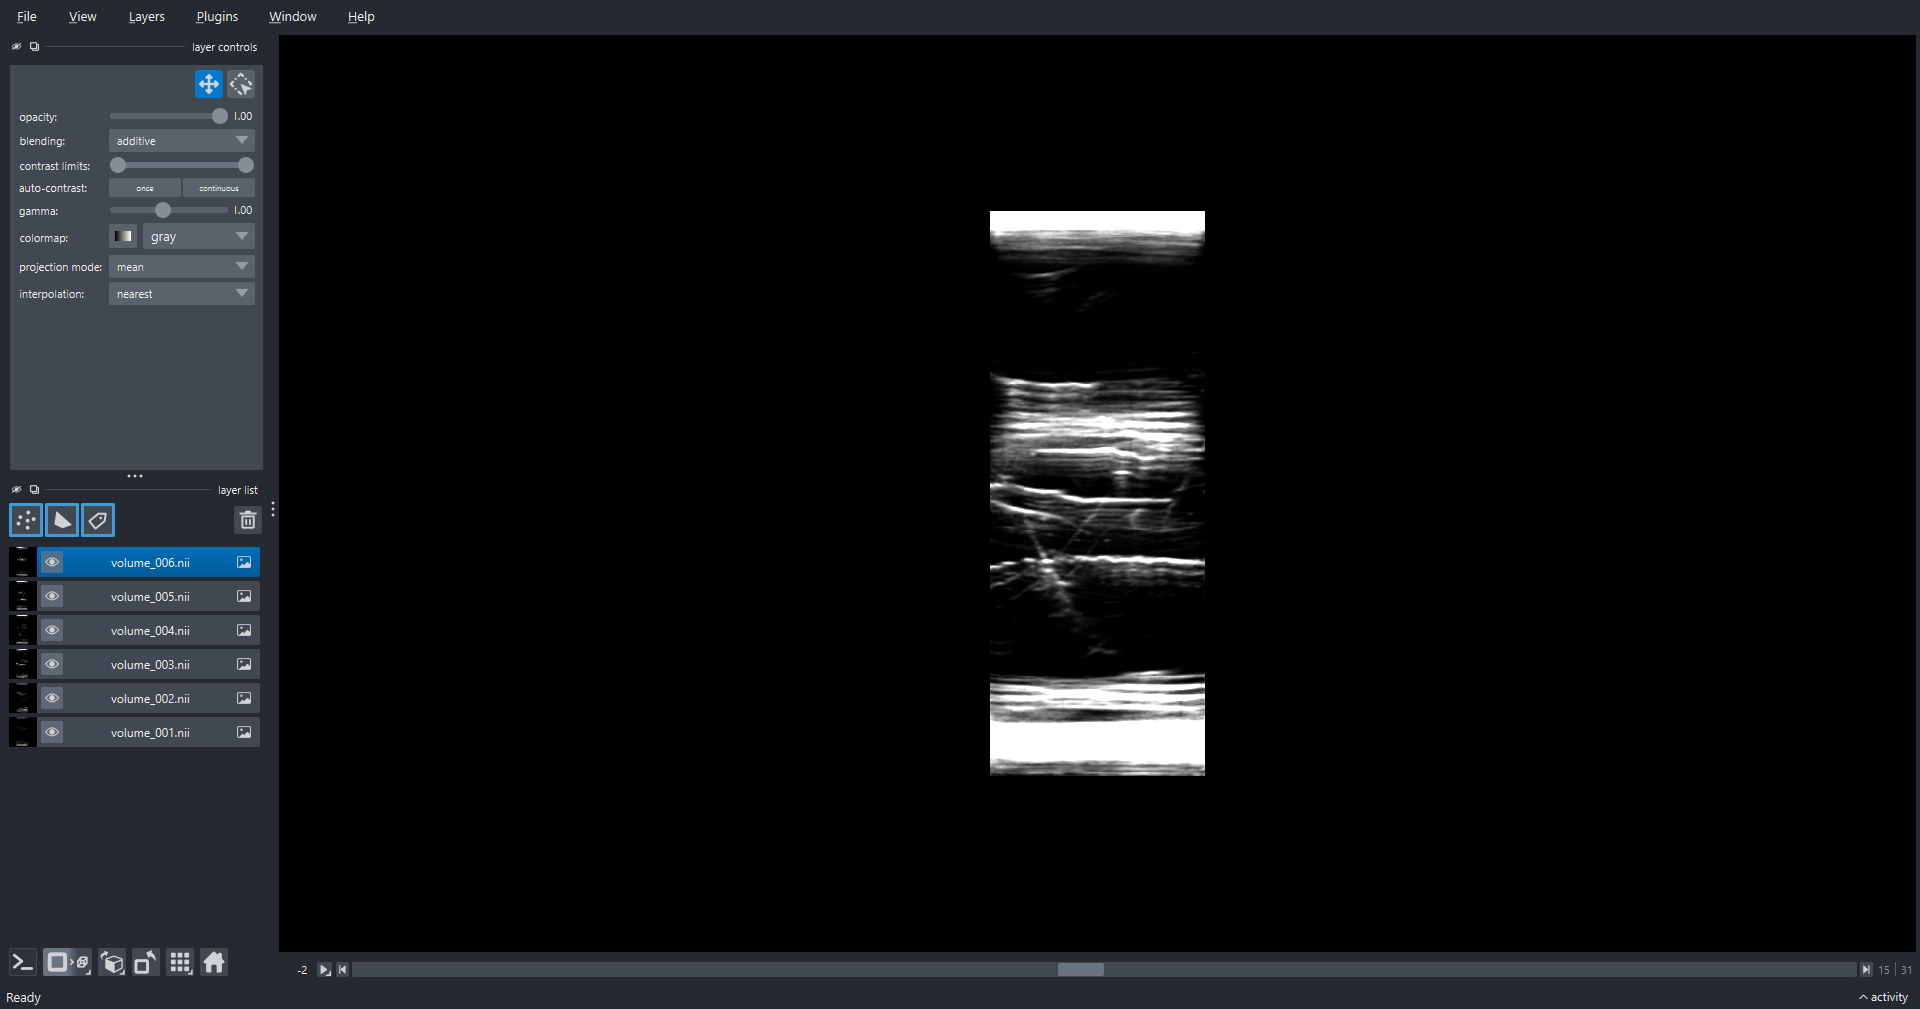

In [20]:
# Napari check of reconstructed volumes
nii_files = sorted(volumes_dir.glob('*.nii.gz'))
if len(nii_files) == 0:
    raise FileNotFoundError(f'No reconstructed volumes found in {volumes_dir}.')

viewer = napari.Viewer(title='Reconstructed Volumes')
for p in nii_files:
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(p)))
    viewer.add_image(arr, name=p.stem, colormap='gray', blending='additive')

nbscreenshot(viewer)

## 6) Register and Fuse Volumes (Current Pipeline: Mean)

In [21]:
registrator = VolumeRegistrator(str(volumes_dir), output_dir=str(results_dir))
fused_path = registrator.process_volumes(output_filename='final_volume_mean_pipeline.nii.gz')
print('Fused output:', fused_path)

Successfully loaded 6 volumes from C:\Users\corba\Documents\eco-root\data\volumes
Processing volume 0 (volume_001)...
Processing volume 1 (volume_002)...
Processing volume 2 (volume_003)...
Processing volume 3 (volume_004)...
Processing volume 4 (volume_005)...
Processing volume 5 (volume_006)...
Fused hexagonal volume saved to: C:\Users\corba\Documents\eco-root\data\results\final_volume_mean_pipeline.nii.gz
Fused output: C:\Users\corba\Documents\eco-root\data\results\final_volume_mean_pipeline.nii.gz


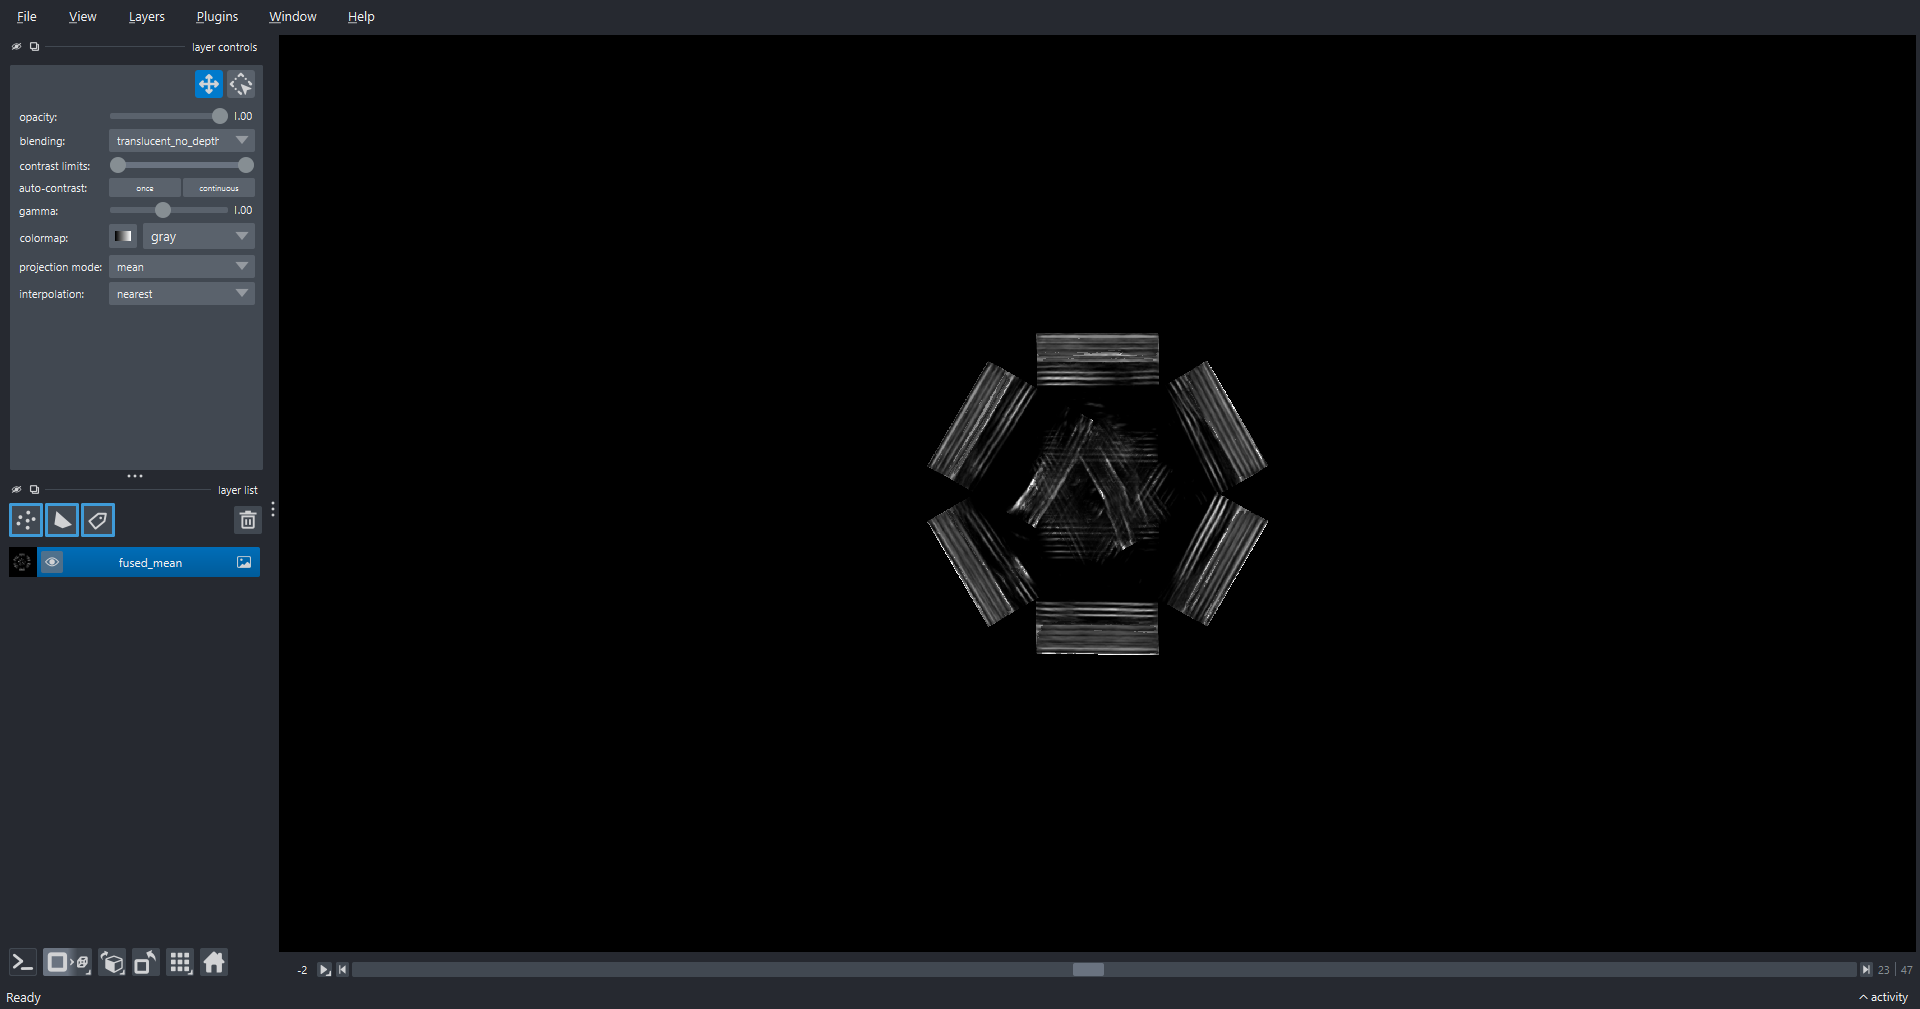

In [23]:
# Napari check of fused volume
if fused_path is None:
    raise RuntimeError('Fusion failed. Check previous cell output.')

fused_img = sitk.ReadImage(str(fused_path))
fused_arr = sitk.GetArrayFromImage(fused_img)

viewer = napari.Viewer(title='Fused Volume (Mean)')
viewer.add_image(fused_arr, name='fused_mean', colormap='gray')
nbscreenshot(viewer)

## 7) Try Alternative Reconstruction/Combination Methods

This section keeps geometry/registration consistent and changes only the voxel-wise fusion operator.

In [9]:
def register_all_to_reference(volumes_dir, angle_per_side=60):
    """Resample each volume into a common reference using the same rotation strategy."""
    reg = VolumeRegistrator(str(volumes_dir), angle_per_side=angle_per_side)
    if not reg.load_volumes():
        raise RuntimeError('Could not load the expected volumes for registration.')

    reference, center = reg.create_reference_volume()
    resampled_arrays = []

    for i, vol in enumerate(reg.volumes):
        t = sitk.Euler3DTransform()
        t.SetCenter(center)
        t.SetRotation(0, 0, np.deg2rad(i * reg.angle_per_side))

        resampled = sitk.Resample(vol, reference, t, sitk.sitkLinear, 0.0, vol.GetPixelID())
        resampled_arrays.append(sitk.GetArrayFromImage(resampled))

    return reference, np.stack(resampled_arrays, axis=0)


def fuse_stack(volume_stack, method='mean', eps=1e-6):
    """Voxel-wise fusion across a stack with shape (n_volumes, z, y, x)."""
    if method == 'mean':
        return np.mean(volume_stack, axis=0)
    if method == 'median':
        return np.median(volume_stack, axis=0)
    if method == 'minimum':
        return np.min(volume_stack, axis=0)
    if method == 'multiplication':
        # Normalize before product to avoid exploding values.
        s = volume_stack.astype(np.float32)
        s = s / (np.max(s, axis=(1, 2, 3), keepdims=True) + eps)
        return np.prod(s + eps, axis=0)
    raise ValueError(f'Unknown method: {method}')

In [10]:
reference_img, registered_stack = register_all_to_reference(volumes_dir)
print('Registered stack shape:', registered_stack.shape)

Successfully loaded 6 volumes from C:\Users\corba\Documents\eco-root\data\volumes
Registered stack shape: (6, 72, 1524, 1533)


In [11]:
methods = ['mean', 'median', 'minimum', 'multiplication']
fused_outputs = {}

for method in methods:
    fused_arr = fuse_stack(registered_stack, method=method)
    fused_img = sitk.GetImageFromArray(fused_arr.astype(np.float32))
    fused_img.CopyInformation(reference_img)

    output_path = results_dir / f'final_volume_{method}.nii.gz'
    sitk.WriteImage(fused_img, str(output_path))
    fused_outputs[method] = output_path

    print(f'{method:>13} -> {output_path.name}')

fused_outputs

         mean -> final_volume_mean.nii.gz
       median -> final_volume_median.nii.gz
      minimum -> final_volume_minimum.nii.gz
multiplication -> final_volume_multiplication.nii.gz


{'mean': WindowsPath('C:/Users/corba/Documents/eco-root/data/results/final_volume_mean.nii.gz'),
 'median': WindowsPath('C:/Users/corba/Documents/eco-root/data/results/final_volume_median.nii.gz'),
 'minimum': WindowsPath('C:/Users/corba/Documents/eco-root/data/results/final_volume_minimum.nii.gz'),
 'multiplication': WindowsPath('C:/Users/corba/Documents/eco-root/data/results/final_volume_multiplication.nii.gz')}

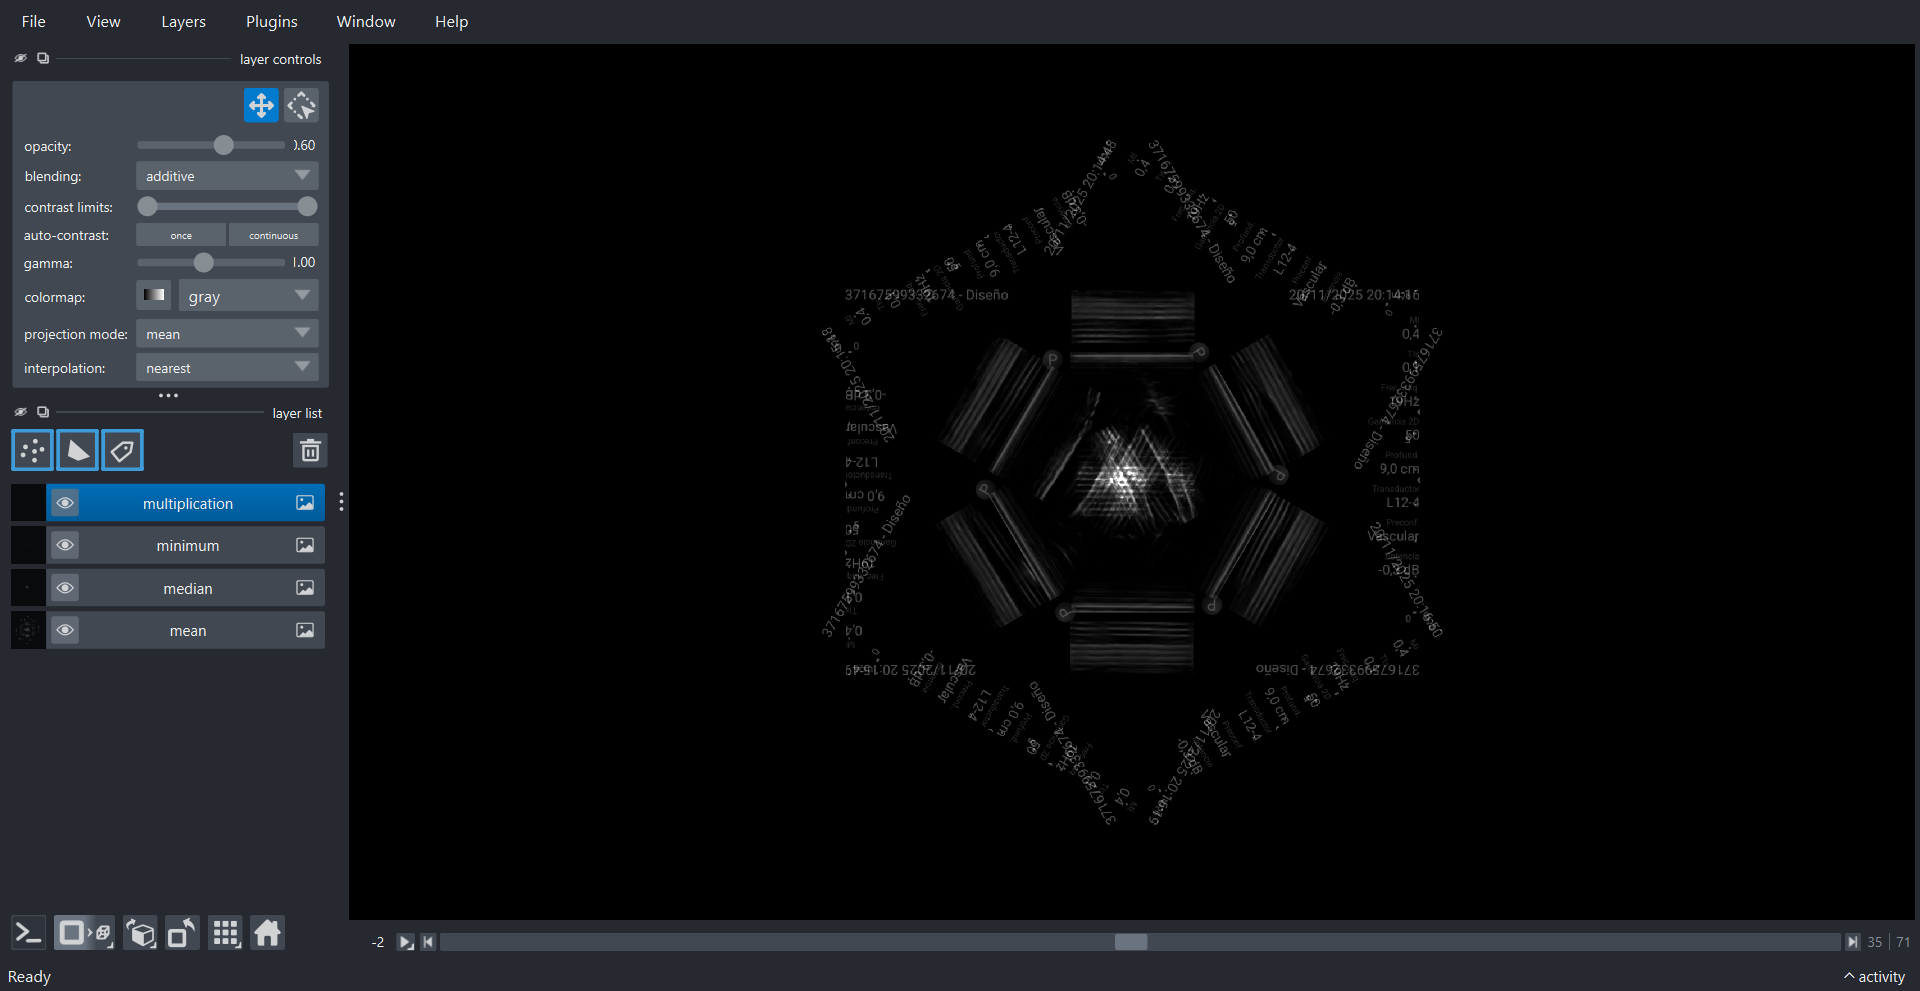

In [12]:
# Visual comparison in Napari
viewer = napari.Viewer(title='Fusion Method Comparison')
for method, p in fused_outputs.items():
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(p)))
    viewer.add_image(arr, name=method, colormap='gray', blending='additive', opacity=0.6)

nbscreenshot(viewer)

## 8) Optional: Quantitative Quick Checks

Use this to compare basic intensity statistics across fusion methods.

In [13]:
for method, p in fused_outputs.items():
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(p)))
    print(
        f'{method:>13}: shape={arr.shape}, min={arr.min():.4f}, max={arr.max():.4f}, '
        f'mean={arr.mean():.4f}, std={arr.std():.4f}'
    )

         mean: shape=(72, 1524, 1533), min=0.0000, max=98.0936, mean=0.6902, std=4.0569
       median: shape=(72, 1524, 1533), min=0.0000, max=94.0913, mean=0.0183, std=0.5751
      minimum: shape=(72, 1524, 1533), min=0.0000, max=40.1325, mean=0.0009, std=0.0785
multiplication: shape=(72, 1524, 1533), min=0.0000, max=0.0001, mean=0.0000, std=0.0000


## 9) Other Packages to Explore for Registration and Reconstruction

You can test additional libraries depending on whether your focus is rigid registration, deformable registration, or volumetric reconstruction quality:

- **SimpleITK / ITK**: broad toolbox for rigid + deformable registration, interpolation, transforms.
- **ANTsPy / ANTsPyx**: state-of-the-art registration workflows (especially deformable).
- **MONAI**: deep learning pipelines for medical image registration and reconstruction tasks.
- **TorchIO**: patch-based medical volume processing and augmentation.
- **scikit-image**: useful baseline methods and image processing utilities.
- **Open3D**: if you move toward point-cloud/surface registration and geometric alignment.

Suggested experiments:
1. Swap rigid Euler transform for affine or B-spline registration.
2. Compare interpolation (nearest, linear, BSpline) during resampling.
3. Add denoising before/after fusion and evaluate segmentation quality impact.
4. Test pairwise registration + global optimization rather than fixed angular assumptions.

In [14]:
# Optional installs (pick based on your environment manager).
# In pixi/conda-forge environments, prefer conda-forge packages when available.

# pip install antspyx monai torchio itk
# pixi add -c conda-forge itk monai
# pixi add -c conda-forge napari

print('Review package options above and install only what you plan to benchmark.')

Review package options above and install only what you plan to benchmark.
